In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
import warnings
from google.colab import drive

# Configs:
warnings.filterwarnings('ignore')
drive.mount('/content/drive')

# Đọc file CSV
data_path = '/content/drive/MyDrive/Colab Notebooks/zomato.csv'
df = pd.read_csv(data_path)

# Hiển thị 5 dòng đầu
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [ ]:
# Làm sạch cột rate
def clean_rate(x):
    try:
        return float(str(x).split('/')[0])
    except:
        return np.nan

df['rate_num'] = df['rate'].apply(clean_rate)

# Làm sạch approx_cost
def clean_cost(x):
    try:
        return float(str(x).replace(',', ''))
    except:
        return np.nan

df['approx_cost'] = df['approx_cost(for two people)'].apply(clean_cost)


In [ ]:
# Ngưỡng phân loại: 3.75
threshold = 3.75
df['target'] = np.where(df['rate_num'] >= threshold, 1, 0)
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),rate_num,approx_cost,target
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,4.1,800.0,1
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,4.1,800.0,1
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,3.8,800.0,1
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,3.7,300.0,0
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,3.8,600.0,1


In [ ]:
# Nhà hàng đã có rate -> dùng train/val
df_trainval = df[df['rate_num'].notna()].copy()

# Nhà hàng chưa có rate -> predict sau
df_new = df[df['rate_num'].isna()].copy()

print(f"Tổng số nhà hàng để Train/Val: {df_trainval.shape[0]}")
print(f"Tổng số nhà hàng NEW để Predict sau: {df_new.shape[0]}")


Tổng số nhà hàng để Train/Val: 41665
Tổng số nhà hàng NEW để Predict sau: 10052


In [ ]:
# multiple_types: Đếm số lượng YES trong online_order, book_table
df_trainval['online_order'] = df_trainval['online_order'].map({'Yes': 1, 'No': 0})
df_trainval['book_table'] = df_trainval['book_table'].map({'Yes': 1, 'No': 0})
df_trainval['multiple_types'] = df_trainval['online_order'] + df_trainval['book_table']

# total_cuisines: Đếm số lượng cuisines
df_trainval['total_cuisines'] = df_trainval['cuisines'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)
df_trainval.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,...,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),rate_num,approx_cost,target,multiple_types,total_cuisines
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,1,1,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,...,800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,4.1,800.0,1,2,3
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,1,0,4.1/5,787,080 41714161,Banashankari,Casual Dining,...,800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,4.1,800.0,1,1,3
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,1,0,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining",...,800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,3.8,800.0,1,1,3
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,0,0,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,...,300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,3.7,300.0,0,0,2
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,0,0,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,...,600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,3.8,600.0,1,0,2


In [ ]:
selected_columns = [
    'online_order', 'book_table', 'location', 'rest_type',
    'listed_in(type)', 'listed_in(city)', 'approx_cost',
    'multiple_types', 'total_cuisines', 'target'
]

df_trainval = df_trainval[selected_columns]

In [ ]:
X = df_trainval.drop('target', axis=1)
y = df_trainval['target']

In [ ]:
# Chọn categorical và numerical
cat_cols = ['location', 'rest_type', 'listed_in(type)', 'listed_in(city)']
num_cols = ['online_order', 'book_table', 'approx_cost', 'multiple_types', 'total_cuisines']

# One-hot encoding
X_cat = pd.get_dummies(X[cat_cols], dummy_na=True)
X_num = X[num_cols]

# Ghép lại
X_final = pd.concat([X_num, X_cat], axis=1)

print(f"Tổng số features sau xử lý: {X_final.shape[1]}")


Tổng số features sau xử lý: 225


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

# Xử lý missing values trước khi train
# =============================
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

import re

def clean_column_names(df):
    df.columns = [re.sub(r'\W+', '_', col) for col in df.columns]  # Thay ký tự đặc biệt thành "_"
    return df

# Làm sạch tên cột
X_train = clean_column_names(X_train)
X_test = clean_column_names(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Huấn luyện nhiều mô hình
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

[LightGBM] [Info] Number of positive: 16195, number of negative: 17137
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001093 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 407
[LightGBM] [Info] Number of data points in the train set: 33332, number of used features: 173
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.485869 -> initscore=-0.056537
[LightGBM] [Info] Start training from score -0.056537


In [ ]:
# Tạo DataFrame kết quả
df_performances = pd.DataFrame(results)

# Hiển thị bảng kết quả có nền màu
df_performances.reset_index(drop=True).style.background_gradient(cmap='Blues')

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.734549,0.762354,0.659175,0.707020
1,Random Forest,0.804872,0.818397,0.769079,0.792972
2,XGBoost,0.797912,0.856497,0.701655,0.771382
3,LightGBM,0.781111,0.836204,0.683379,0.752107


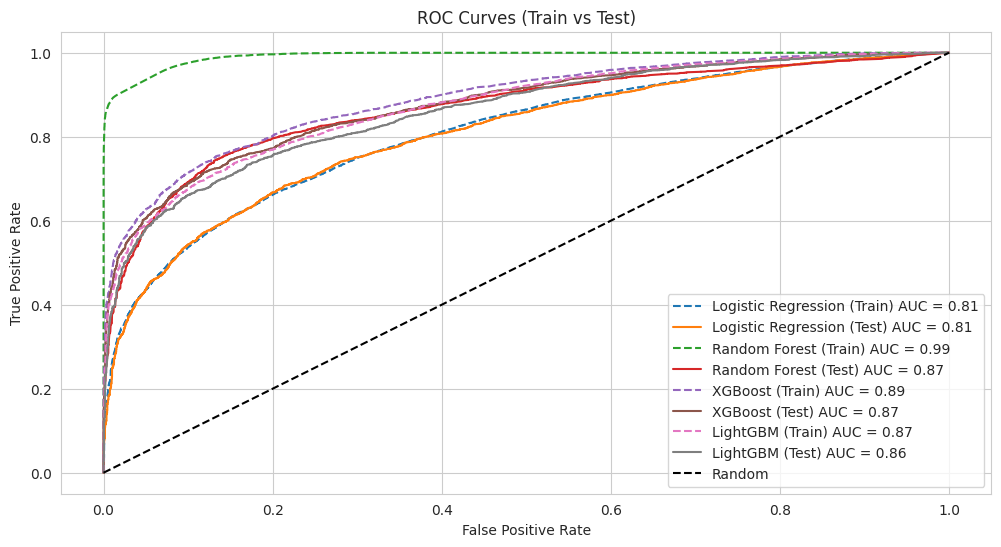

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Vẽ ROC Curve cho cả train và test
def plot_roc_curves(models, X_train, y_train, X_test, y_test):
    plt.figure(figsize=(12, 6))

    for i, (name, model) in enumerate(models.items(), 1):
        for dataset, X, y, color in [('Train', X_train, y_train, 'blue'), ('Test', X_test, y_test, 'red')]:
            if hasattr(model, "predict_proba"):
                y_scores = model.predict_proba(X)[:, 1]
            else:
                y_scores = model.decision_function(X)

            fpr, tpr, _ = roc_curve(y, y_scores)
            roc_auc = auc(fpr, tpr)

            plt.plot(fpr, tpr, label=f'{name} ({dataset}) AUC = {roc_auc:.2f}', linestyle='--' if dataset=='Train' else '-')

    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.title('ROC Curves (Train vs Test)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

# Gọi hàm
plot_roc_curves(models, X_train, y_train, X_test, y_test)

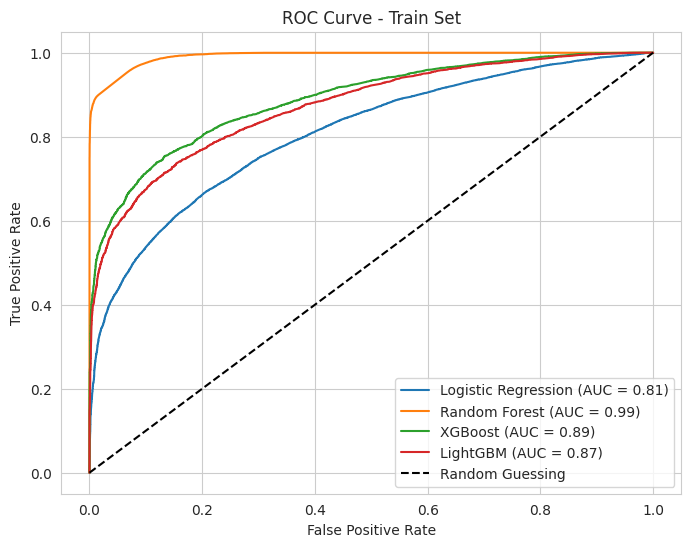

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc(data_type, models, X, y):
    plt.figure(figsize=(8, 6))

    for name, model in models.items():
        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X)[:, 1]
        else:
            y_scores = model.decision_function(X)

        fpr, tpr, _ = roc_curve(y, y_scores)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
    plt.title(f'ROC Curve - {data_type} Set')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

# Vẽ riêng cho tập train
plot_roc("Train", models, X_train, y_train)

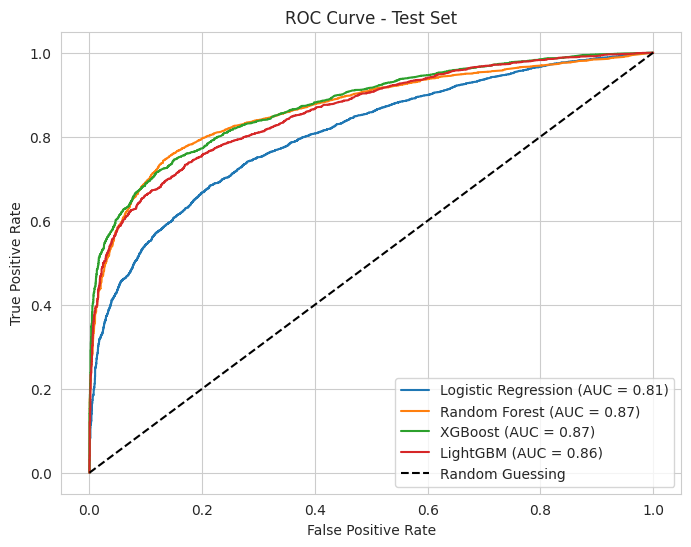

In [ ]:
# Vẽ riêng cho tập test
plot_roc("Test", models, X_test, y_test)


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_train_test_cm_side_by_side(model, X_train, y_train, X_test, y_test, model_name, classes=['Good', 'Bad']):
    # Dự đoán
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Tính confusion matrix
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_test = confusion_matrix(y_test, y_test_pred)

    # Vẽ subplot
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=axes[0])
    axes[0].set_title(f'{model_name} - Train')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
                xticklabels=classes, yticklabels=classes, ax=axes[1])
    axes[1].set_title(f'{model_name} - Test')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

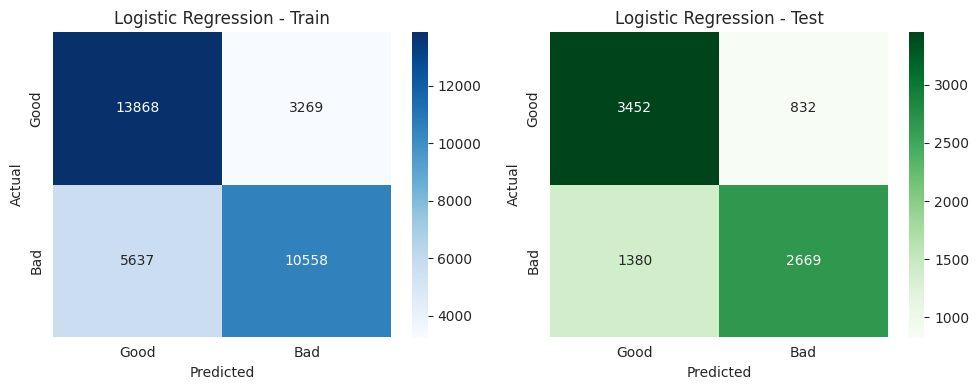

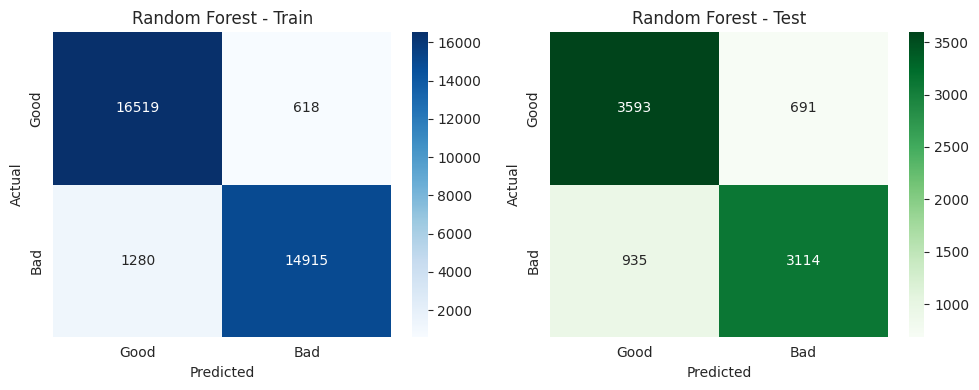

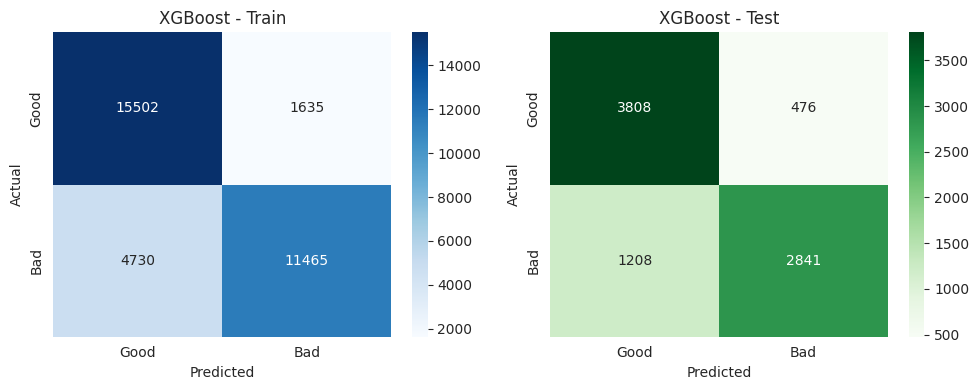

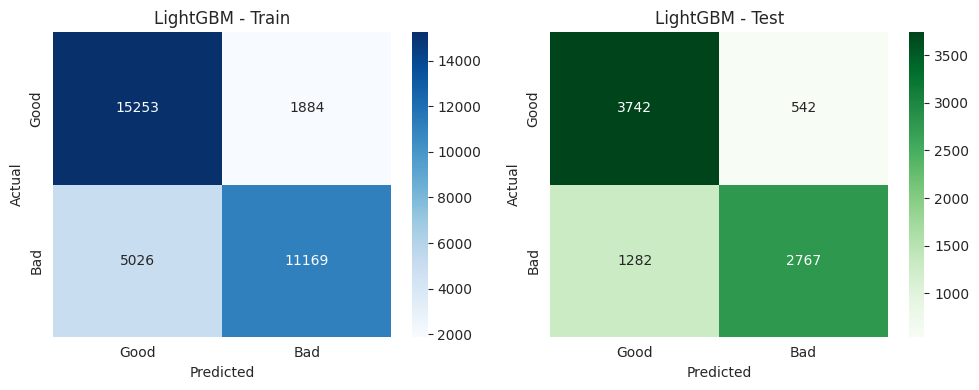

In [ ]:
for name, model in models.items():
    plot_train_test_cm_side_by_side(model, X_train, y_train, X_test, y_test, model_name=name)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_feature_importance(model, feature_names, model_name='Model', top_n=20, ax=None):
    # Lấy độ quan trọng
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = model.coef_.ravel()
    else:
        raise ValueError("Model không hỗ trợ feature_importance.")

    # Tạo DataFrame
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values(by='Importance', ascending=False).head(top_n)

    # Vẽ
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    fi_df.plot(kind='barh', x='Feature', y='Importance', ax=ax, legend=False)
    ax.invert_yaxis()
    ax.set_title(f'{model_name} - Top {top_n} Feature Importances')
    ax.set_xlabel('Importance')
    ax.set_ylabel('Feature')

    return fi_df

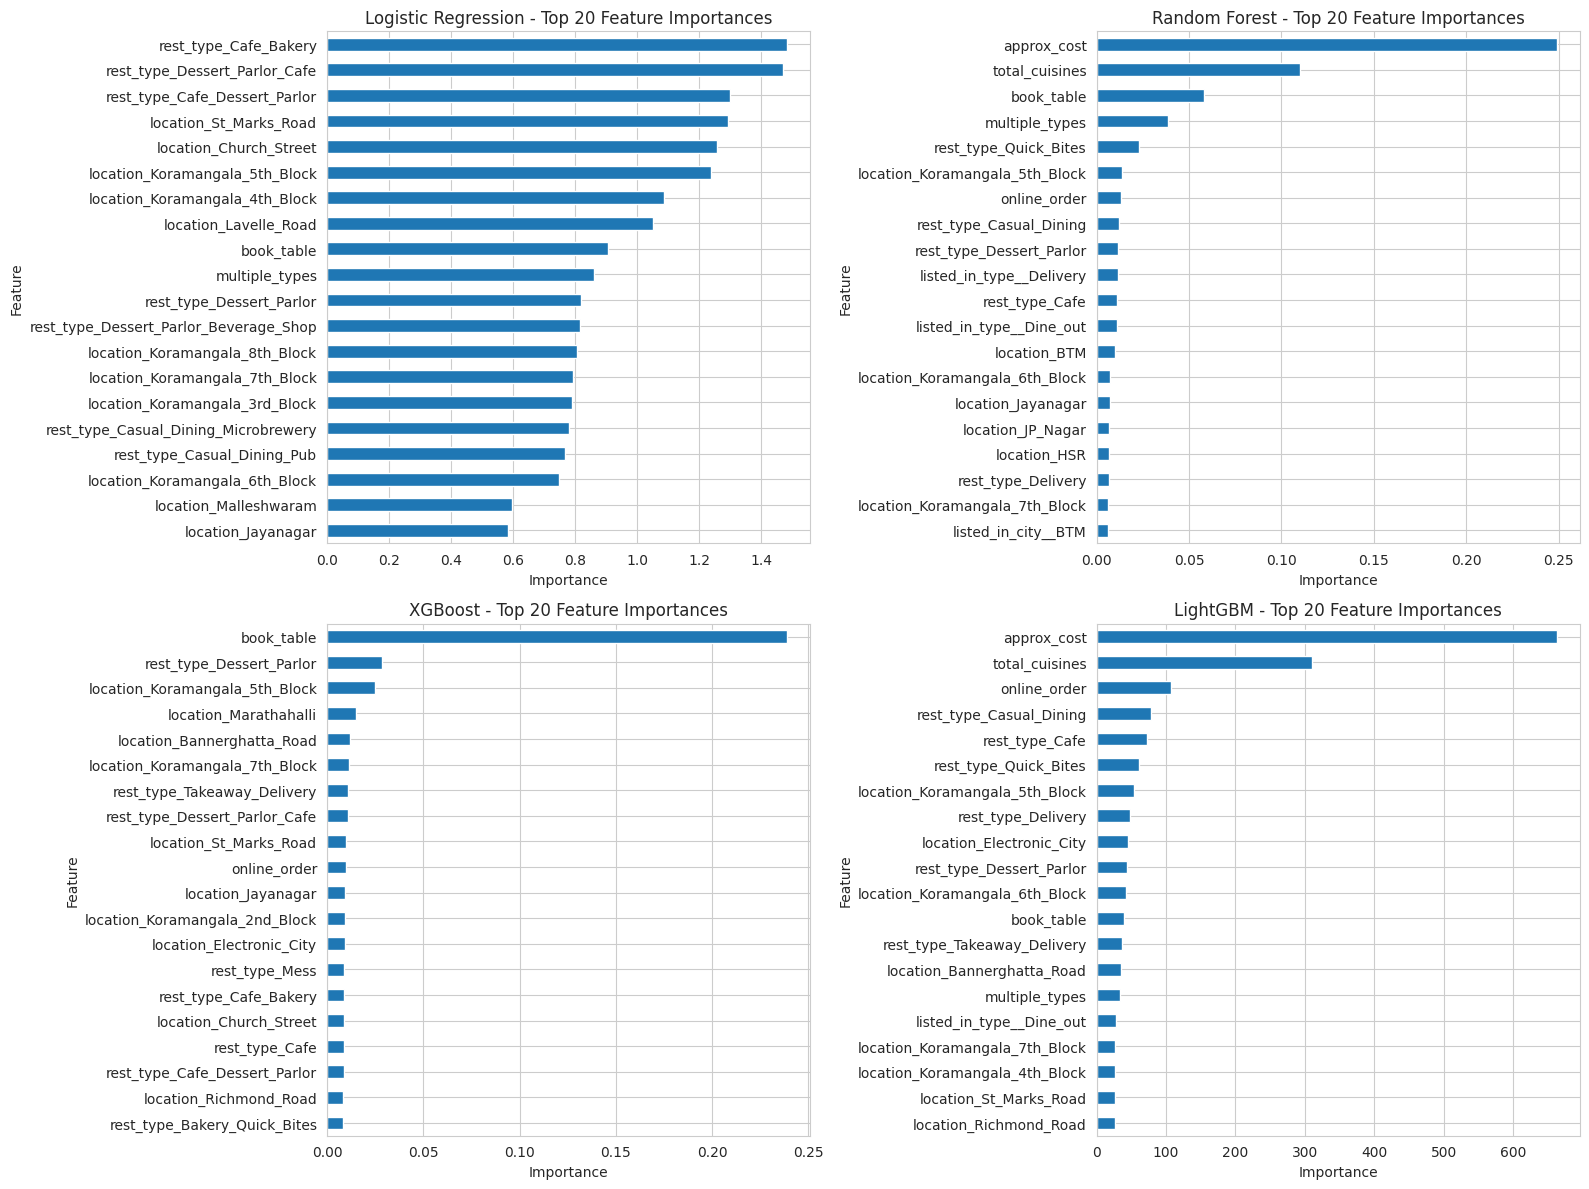

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))  # 2 hàng, 2 cột
axes = axes.flatten()  # Chuyển thành 1 chiều để dễ truy cập

model_names = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']

for i, name in enumerate(model_names):
    model = models[name]
    plot_feature_importance(model, feature_names=X_train.columns, model_name=name, ax=axes[i])

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_score_distribution(model, X_train, y_train, X_test, y_test, model_name='Model', ax=None, shade=True):
    if not hasattr(model, "predict_proba"):
        raise ValueError(f"Model {model_name} không có phương thức predict_proba.")

    # Dự đoán xác suất lớp 1
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Biểu đồ phân phối cho cả train và test
    sns.kdeplot(train_proba[y_train == 0], label="Train y=0", shade=shade, ax=ax, linestyle="--", color="blue")
    sns.kdeplot(train_proba[y_train == 1], label="Train y=1", shade=shade, ax=ax, linestyle="--", color="red")
    sns.kdeplot(test_proba[y_test == 0], label="Test y=0", shade=shade, ax=ax, color="blue")
    sns.kdeplot(test_proba[y_test == 1], label="Test y=1", shade=shade, ax=ax, color="red")

    ax.set_title(f"{model_name} - Score Distribution")
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Density")
    ax.legend()

    return ax


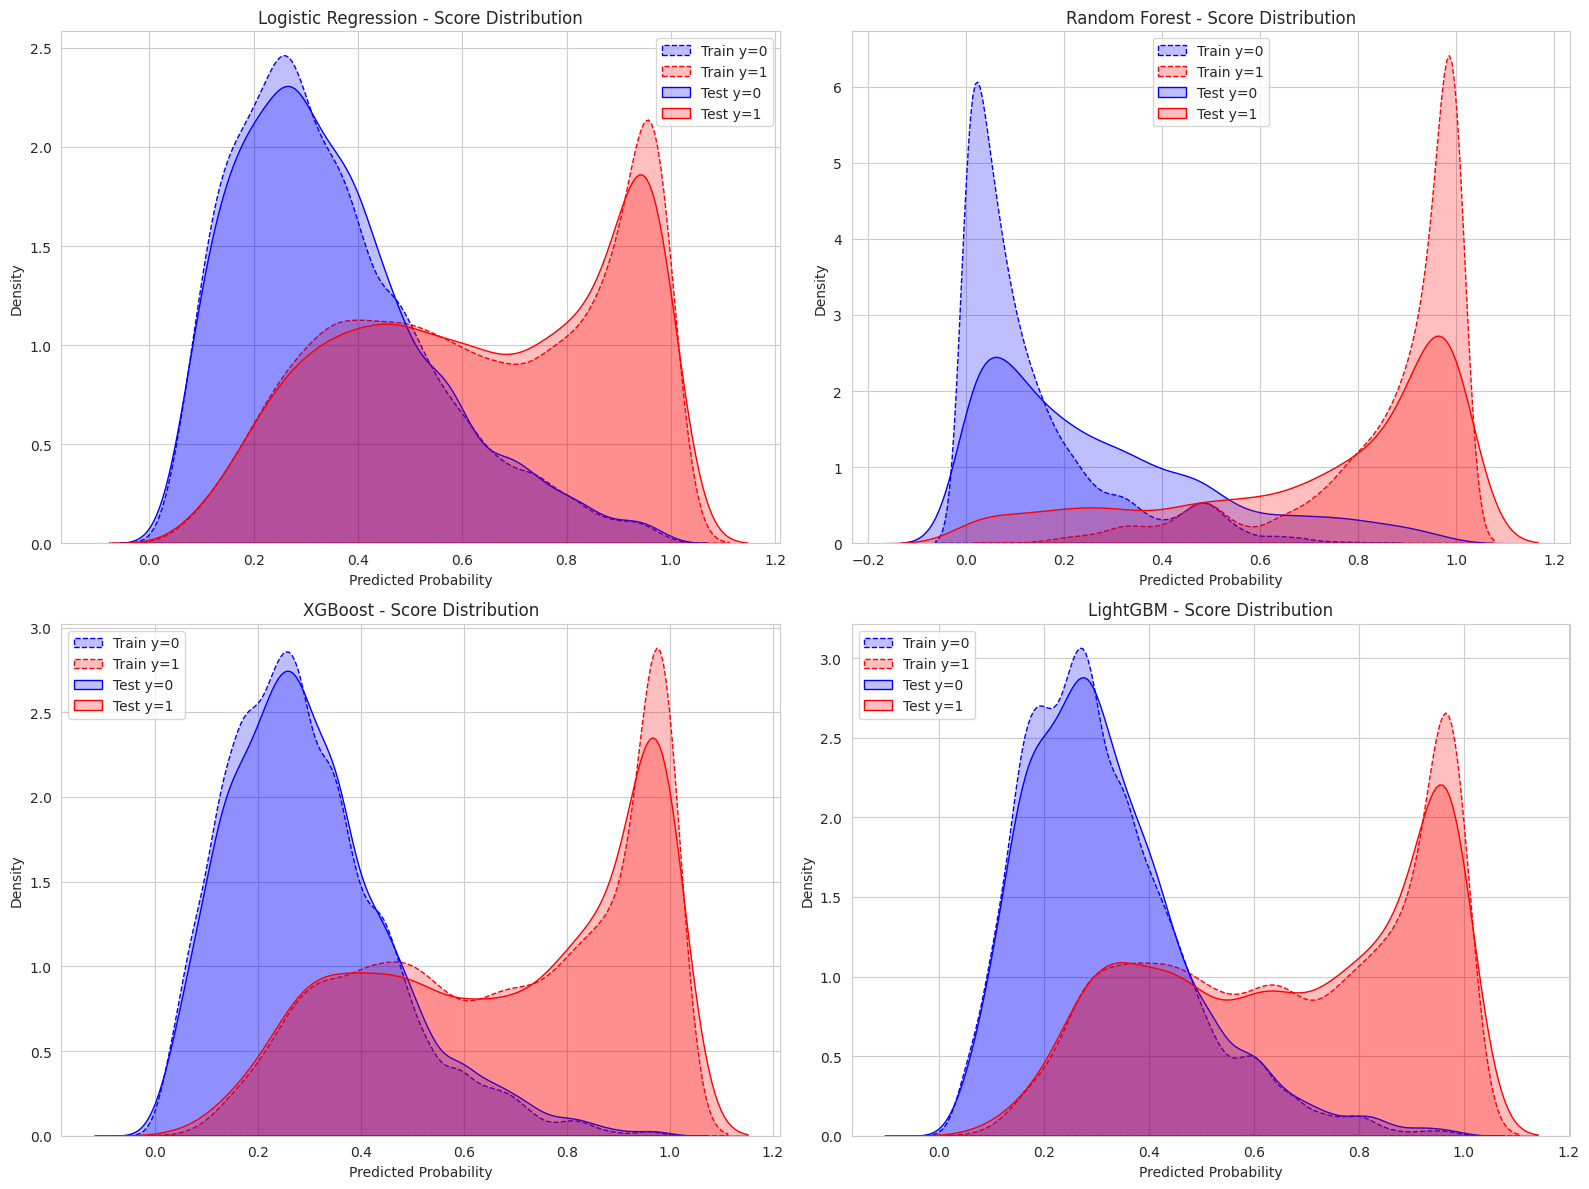

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

model_names = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']

for i, name in enumerate(model_names):
    model = models[name]
    plot_score_distribution(model, X_train, y_train, X_test, y_test, model_name=name, ax=axes[i])

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_score_distribution_single(model, X, y, model_name='Model', dataset_type='Train', ax=None, shade=True):
    if not hasattr(model, "predict_proba"):
        raise ValueError(f"Model {model_name} không có phương thức predict_proba.")

    proba = model.predict_proba(X)[:, 1]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    sns.kdeplot(proba[y == 0], label="y=0", shade=shade, ax=ax, color="blue")
    sns.kdeplot(proba[y == 1], label="y=1", shade=shade, ax=ax, color="red")

    ax.set_title(f"{model_name} - {dataset_type} Set")
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Density")
    ax.legend()

    return ax


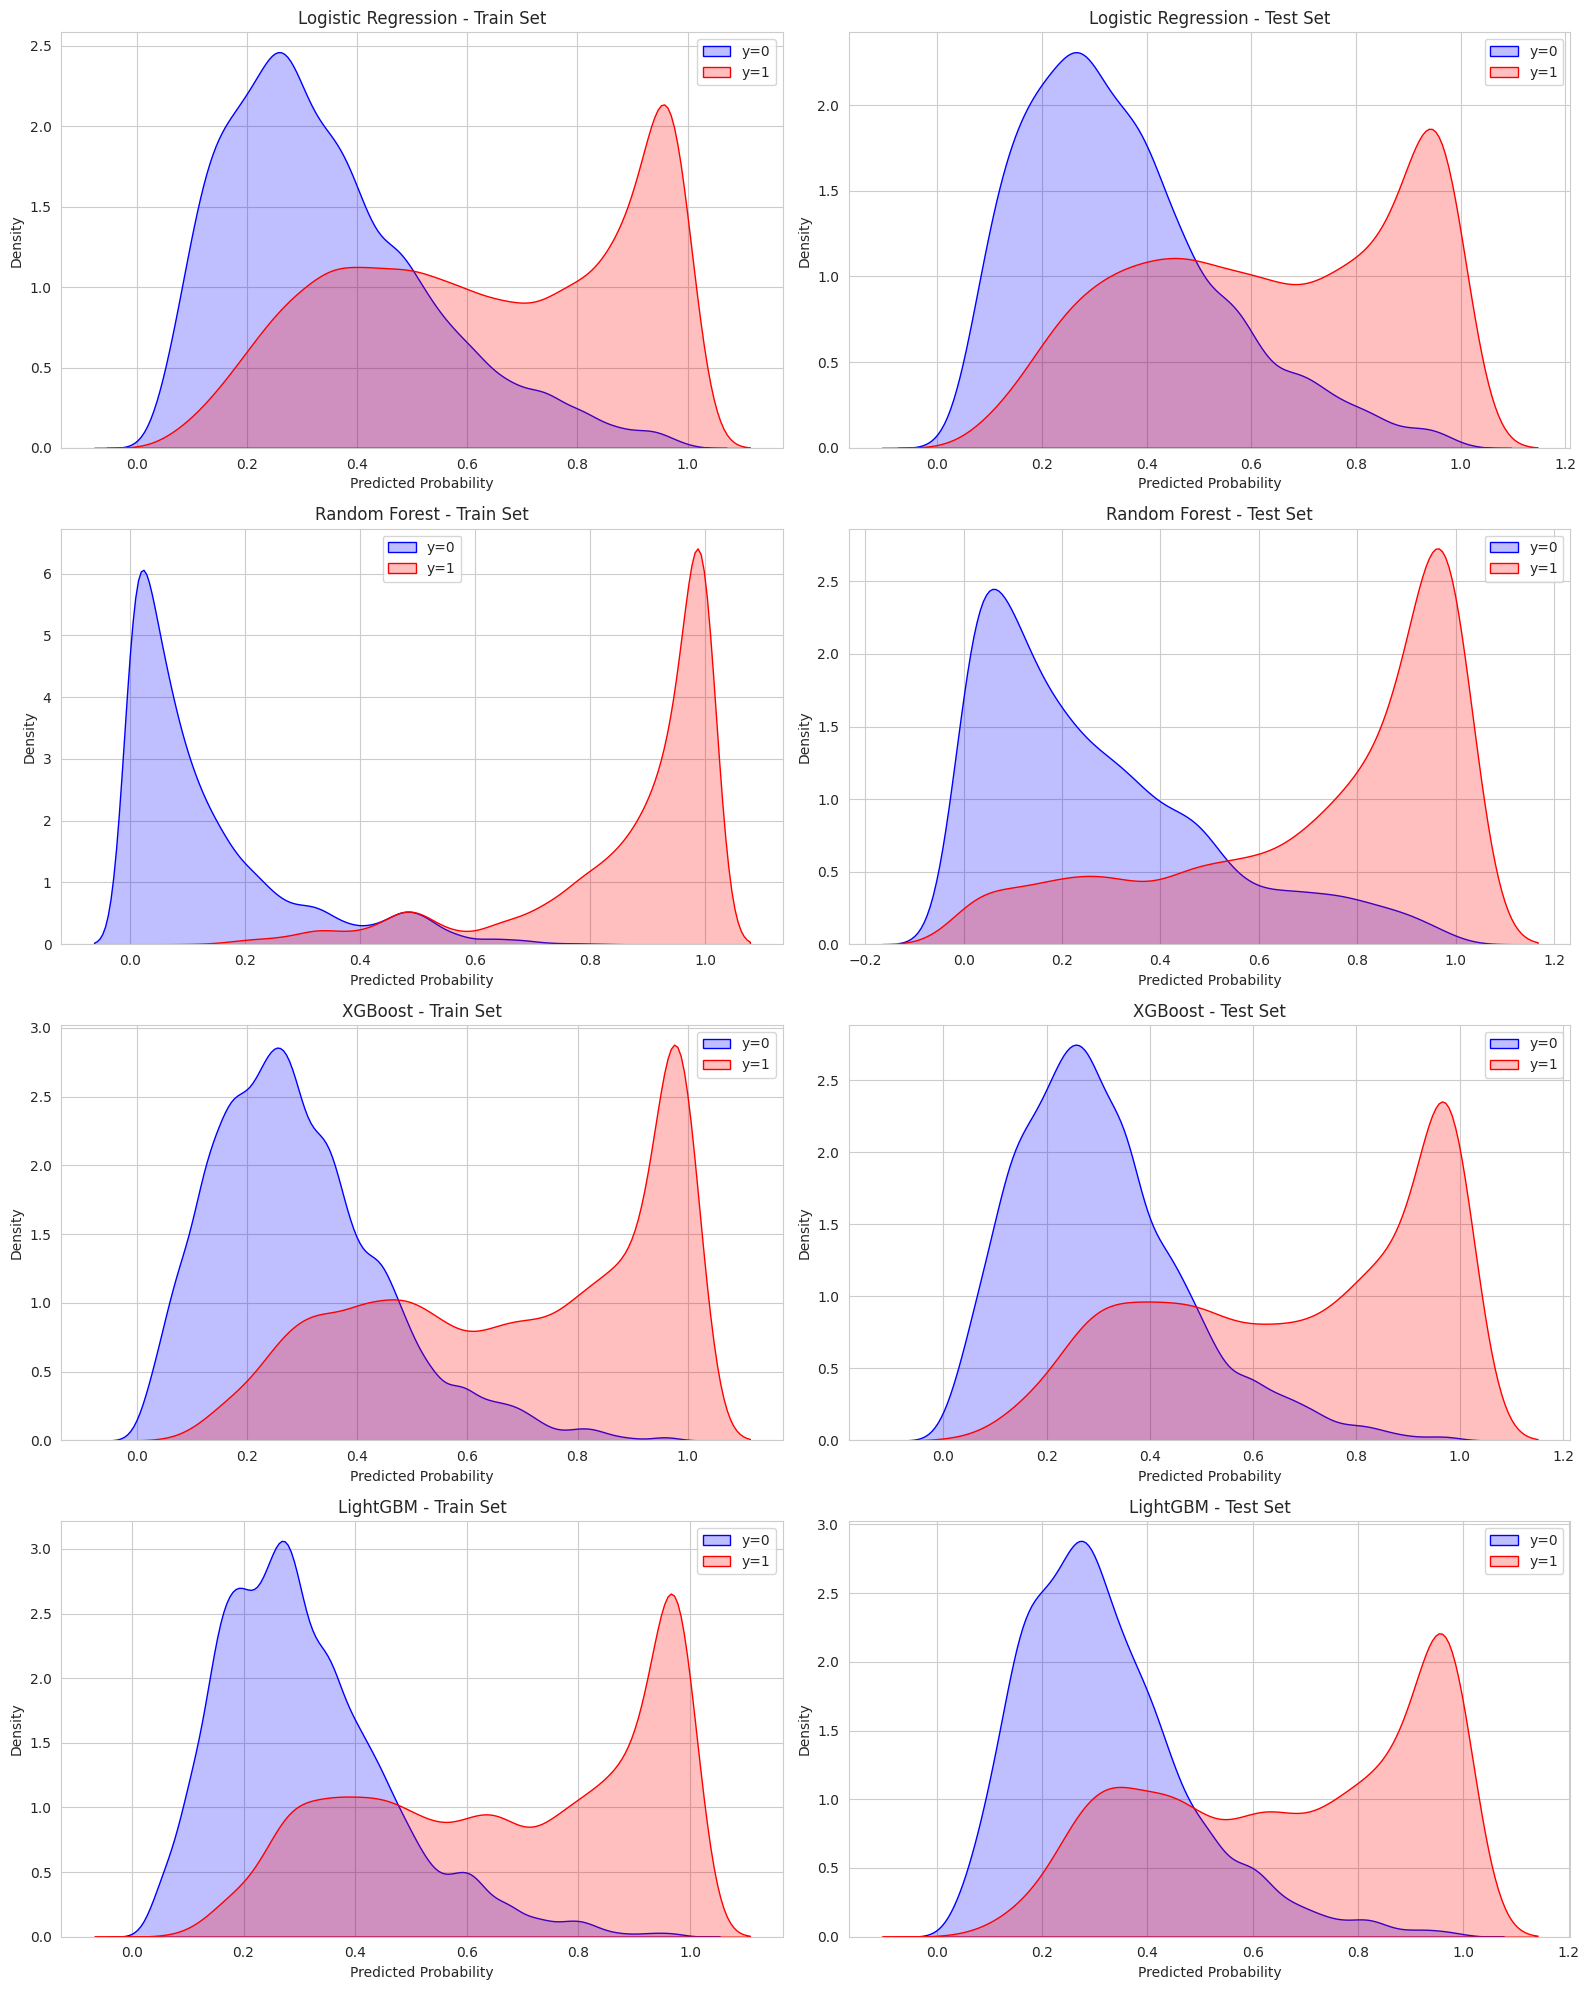

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))  # 4 hàng, 2 cột
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']

for i, name in enumerate(model_names):
    model = models[name]
    plot_score_distribution_single(model, X_train, y_train, model_name=name, dataset_type="Train", ax=axes[i, 0])
    plot_score_distribution_single(model, X_test, y_test, model_name=name, dataset_type="Test", ax=axes[i, 1])

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_score_histogram_by_bins(model, X, y, model_name='Model', dataset_type='Train', ax=None, bins=np.linspace(0, 1, 11)):
    if not hasattr(model, "predict_proba"):
        raise ValueError(f"Model {model_name} không có phương thức predict_proba.")

    proba = model.predict_proba(X)[:, 1]
    df = pd.DataFrame({'proba': proba, 'target': y})
    df['faixa'] = pd.cut(df['proba'], bins=bins, include_lowest=True)

    sns.set_style("whitegrid")
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Vẽ countplot
    plot = sns.countplot(data=df, x='faixa', hue='target', palette='coolwarm', ax=ax)
    ax.set_title(f"{model_name} - Quantity by Range - {dataset_type}")
    ax.set_xlabel("Probability Range")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)

    # Thêm số trên mỗi cột
    for container in plot.containers:
        plot.bar_label(container, fmt='%d', label_type='edge', fontsize=8, padding=2)

    return ax


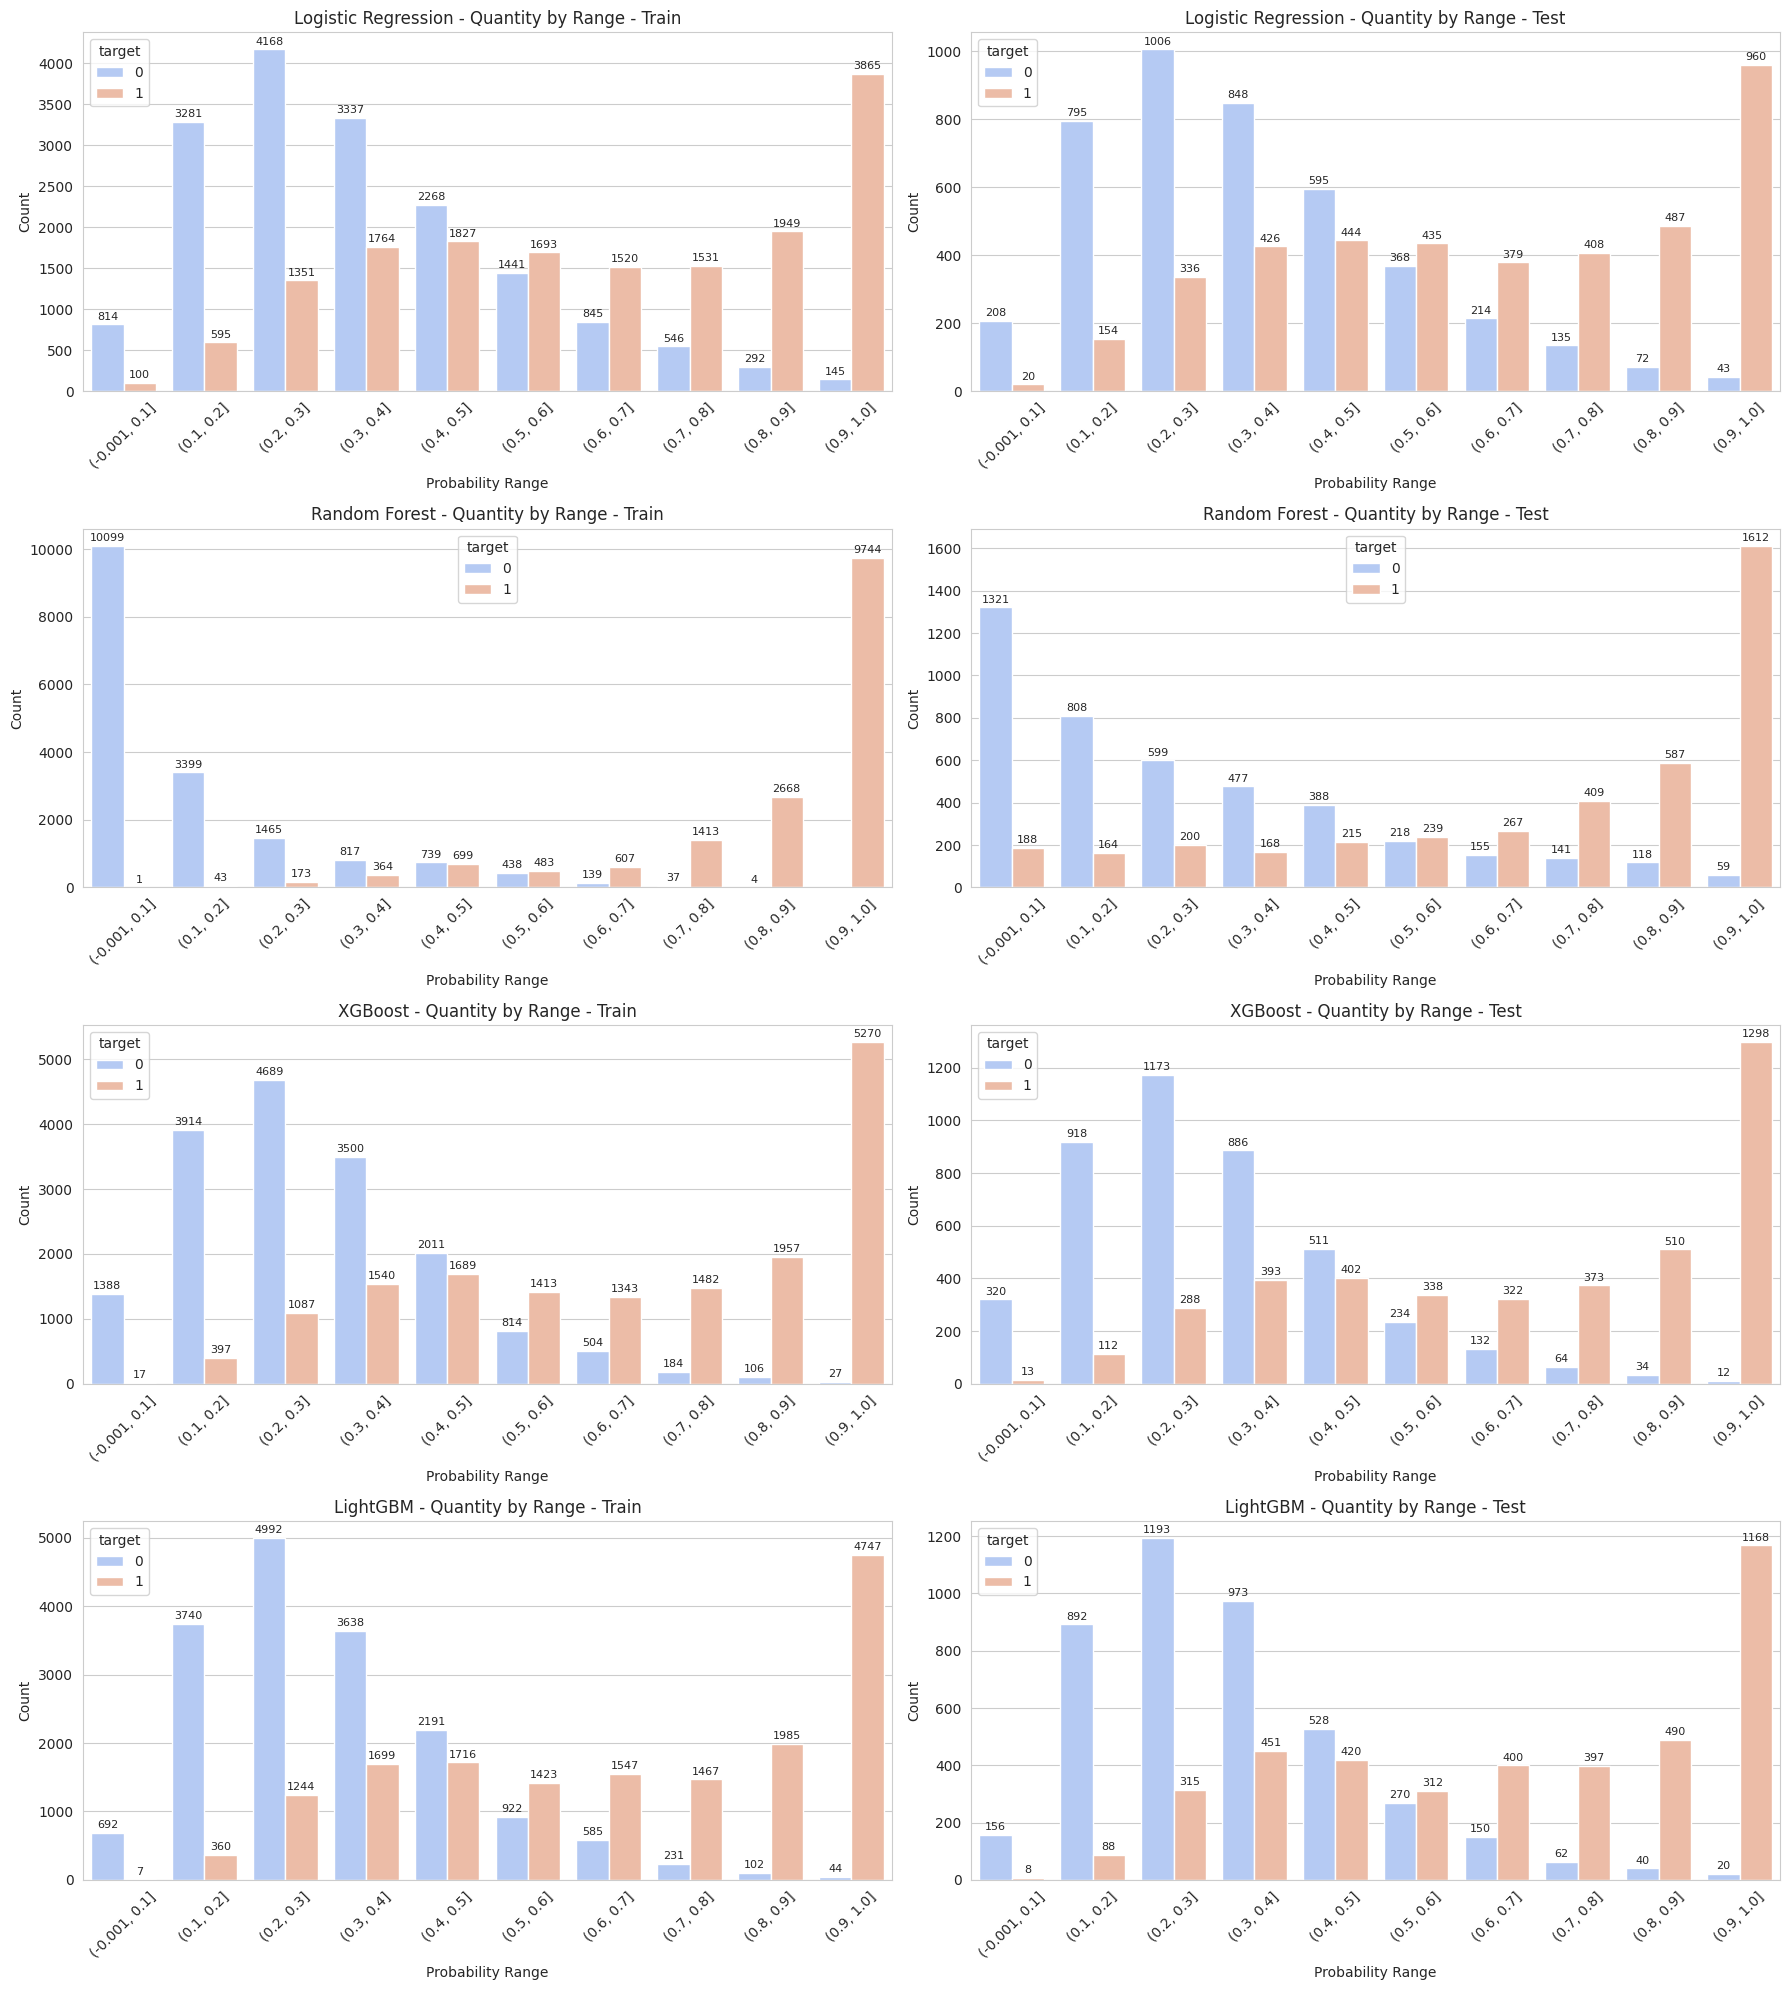

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(18, 20))  # 4 mô hình × 2 bộ dữ liệu
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']

for i, name in enumerate(model_names):
    model = models[name]
    plot_score_histogram_by_bins(model, X_train, y_train, model_name=name, dataset_type="Train", ax=axes[i, 0])
    plot_score_histogram_by_bins(model, X_test, y_test, model_name=name, dataset_type="Test", ax=axes[i, 1])

plt.tight_layout()
plt.show()


In [ ]:
!pip install shap --quiet

import shap
import matplotlib.pyplot as plt


In [ ]:
X_train_shap = X_train.copy()
X_test_shap = X_test.copy()

# Chuyển tất cả các cột về float nếu có thể
X_train_shap = X_train_shap.apply(pd.to_numeric, errors='coerce')
X_test_shap = X_test_shap.apply(pd.to_numeric, errors='coerce')

# Nếu còn missing, thay thế bằng 0 hoặc median tuỳ chiến lược
X_train_shap.fillna(0, inplace=True)
X_test_shap.fillna(0, inplace=True)

def shap_dot_summary_fixed(model, X, model_name="Model", dataset_type="Train"):
    print(f"\n🔍 SHAP Summary Plot for: {model_name} [{dataset_type}]")

    try:
        model_type = model.__class__.__name__

        if model_type == "LGBMClassifier":
            explainer = shap.TreeExplainer(model)
        elif model_type == "XGBClassifier" or model_type == "RandomForestClassifier":
            explainer = shap.Explainer(model, X)
        elif model_type == "LogisticRegression":
            explainer = shap.Explainer(model.predict_proba, X)
        else:
            print(f"⚠️ Không hỗ trợ SHAP cho mô hình {model_type}")
            return

        shap_values = explainer(X)
        shap.summary_plot(shap_values, X, show=True, plot_type="dot")

    except Exception as e:
        print(f"❌ Lỗi khi xử lý {model_name} - {dataset_type}: {e}")



🔍 SHAP Summary Plot for: Logistic Regression [Train]
❌ Lỗi khi xử lý Logistic Regression - Train: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

🔍 SHAP Summary Plot for: Logistic Regression [Test]
❌ Lỗi khi xử lý Logistic Regression - Test: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

🔍 SHAP Summary Plot for: Random Forest [Train]
❌ Lỗi khi xử lý Random Forest - Train: Cannot cast array data from dtype('O') to dtype('float64') according to the rule 'safe'

🔍 SHAP Summary Plot for: Random Forest [Test]
❌ Lỗi khi xử lý Random Forest - Test: Cannot cast array data from dtype('O') to dtype('float64') according to the rule 'safe'

🔍 SHAP Summary Plot for: XGBoost [Train]
❌ Lỗi khi xử lý XGBoost - Train: Cannot cast array data from dtype('O') to dtype('float64') accordin

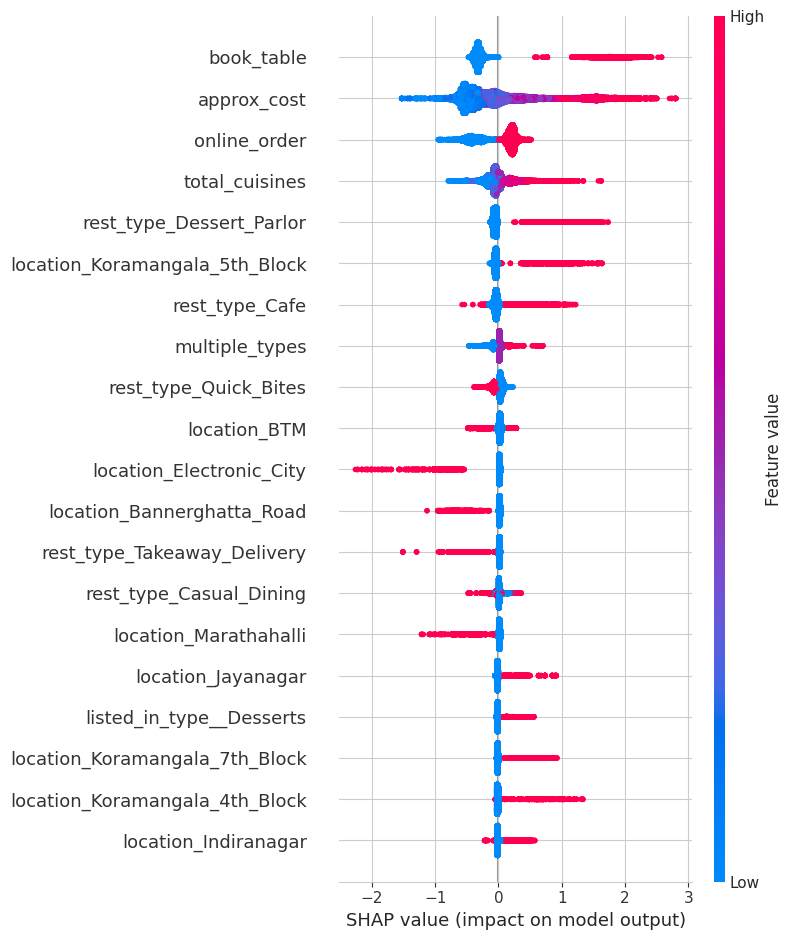


🔍 SHAP Summary Plot for: LightGBM [Test]


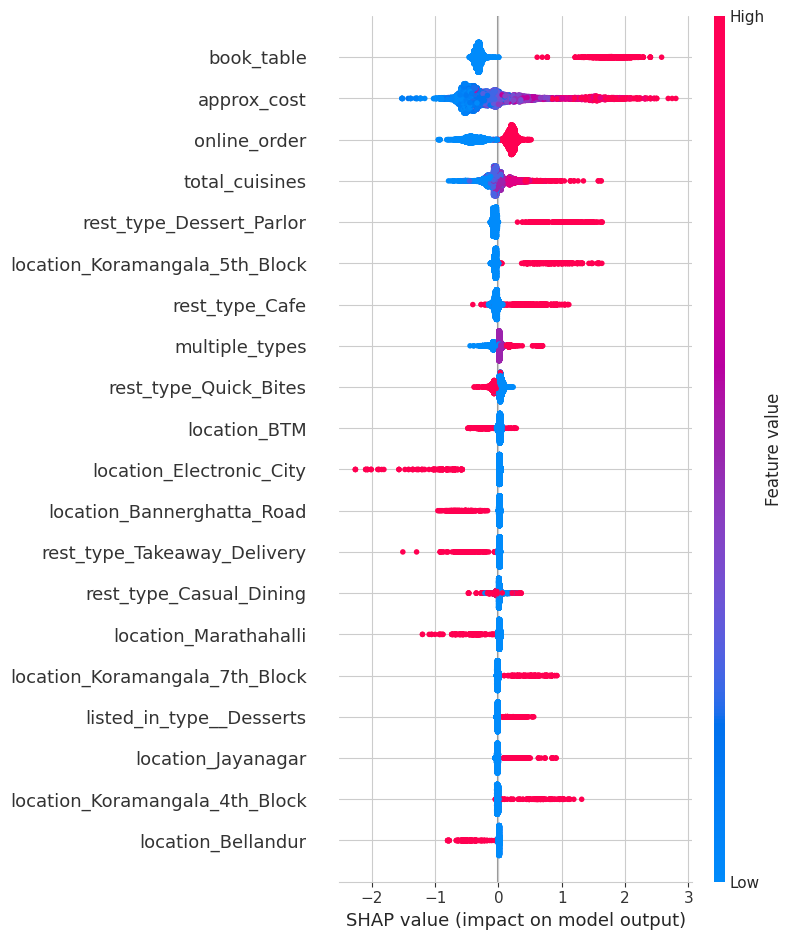

In [ ]:
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']

for name in model_names:
    model = models[name]
    shap_dot_summary_fixed(model, X_train_shap, model_name=name, dataset_type="Train")
    shap_dot_summary_fixed(model, X_test_shap, model_name=name, dataset_type="Test")

Dự đoán cho nhà hàng mới

In [ ]:
# 0. Drop target nếu có
df_new = df_new.drop(columns='target', errors='ignore')

# 1. Làm sạch rate
def clean_rate(x):
    try:
        return float(x.split('/')[0])
    except:
        return np.nan

if 'rate' in df_new.columns:
    df_new['rate'] = df_new['rate'].apply(clean_rate)

# 2. Đặc trưng bổ sung
df_new['multiple_types'] = df_new['rest_type'].apply(lambda x: 1 if isinstance(x, str) and ',' in x else 0)
df_new['total_cuisines'] = df_new['cuisines'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)

# 3. Đổi tên cost nếu cần
if 'approx_cost(for two people)' in df_new.columns:
    df_new = df_new.rename(columns={'approx_cost(for two people)': 'approx_cost'})

# 4. Chọn và xử lý features
cat_cols = ['location', 'rest_type', 'listed_in(type)', 'listed_in(city)']
num_cols = ['online_order', 'book_table', 'approx_cost', 'multiple_types', 'total_cuisines']

X_cat = pd.get_dummies(df_new[cat_cols], dummy_na=True)
X_num = df_new[num_cols]
df_new_encoded = pd.concat([X_num, X_cat], axis=1)

# 5. Chuẩn hóa cột khớp với X_train
missing = set(X_train.columns) - set(df_new_encoded.columns)
extra = set(df_new_encoded.columns) - set(X_train.columns)

for col in missing:
    df_new_encoded[col] = 0

df_new_encoded = df_new_encoded.drop(columns=extra)

In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"df_new_encoded shape: {df_new_encoded.shape}")


X_train shape: (33332, 225)
df_new_encoded shape: (10052, 226)


In [ ]:
# 1. Giữ lại các cột numeric
df_new_encoded = df_new_encoded.select_dtypes(include='number')

# 2. Bổ sung các cột còn thiếu
missing_cols = set(X_train.columns) - set(df_new_encoded.columns)
for col in missing_cols:
    df_new_encoded[col] = 0

# 3. Loại bỏ cột dư (có trong df_new_encoded nhưng không có trong X_train)
df_new_encoded = df_new_encoded[X_train.columns]

# 4. Đảm bảo đúng kiểu dữ liệu float
df_new_encoded = df_new_encoded.astype(float)

# 5. Kiểm tra kết quả
print(f"✅ df_new_encoded ready: {df_new_encoded.shape} == X_train {X_train.shape}")

✅ df_new_encoded ready: (10052, 225) == X_train (33332, 225)


In [ ]:
# Dự đoán xác suất thành công cho nhà hàng mới
# Lấy mô hình LightGBM đã huấn luyện
model = models['LightGBM']

# Dự đoán
y_pred = model.predict(df_new_encoded)
y_proba = model.predict_proba(df_new_encoded)[:, 1]

# Gắn kết quả vào df_new
df_new['success_class'] = y_pred
df_new['success_proba'] = y_proba

# Hiển thị kết quả
df_new[['success_class', 'success_proba']].head()

,success_class,success_proba
72,0,0.220410
75,0,0.320199
84,0,0.216461
90,0,0.308663
91,0,0.265786


In [ ]:
df_new.head(3)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,...,reviews_list,menu_item,listed_in(type),listed_in(city),rate_num,approx_cost,multiple_types,total_cuisines,success_class,success_proba
72,https://www.zomato.com/bangalore/spicy-tandoor...,"Opposite ICICi Bank, Hanuman Nagar, Banashanka...",Spicy Tandoor,No,No,NaN,0,+91 8050884222,Banashankari,Quick Bites,...,"[('Rated 4.0', 'RATED\n cost for chicken roll...",[],Delivery,Banashankari,NaN,150.0,0,1,0,0.220410
75,https://www.zomato.com/bangalore/om-sri-vinaya...,"39, S B M Colony, Near-Sita Circle, 1st Stage,...",Om Sri Vinayaka Chats,No,No,NaN,0,+91 8553206035,Banashankari,"Takeaway, Delivery",...,[],[],Delivery,Banashankari,NaN,500.0,1,2,0,0.320199
84,https://www.zomato.com/bangalore/chill-out-ban...,"161/C, 6th Main, 80 Feet Road, Bhuvaneshwari N...",Chill Out,No,No,NaN,0,+91 9341215167,Banashankari,Quick Bites,...,"[('Rated 4.0', 'RATED\n Good Location. Small ...",[],Delivery,Banashankari,NaN,100.0,0,2,0,0.216461


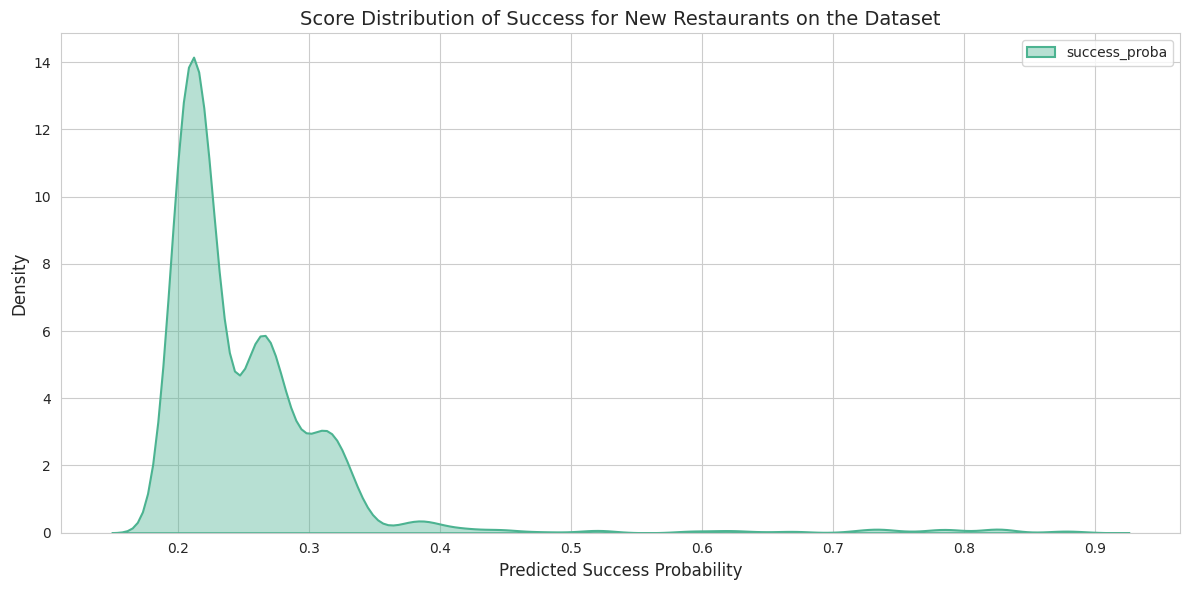

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vẽ KDE plot cho phân phối xác suất thành công
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.kdeplot(data=df_new, x='success_proba', fill=True,color="#4CB391",  # Màu xanh ngọc
    linewidth=1.5,
    alpha=0.4, label='success_proba')

# Trang trí biểu đồ
plt.title('Score Distribution of Success for New Restaurants on the Dataset', fontsize=14)
plt.xlabel('Predicted Success Probability', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
top_restaurants = df_new.sort_values(by='success_proba', ascending=False).head(10)
top_restaurants[['success_class', 'success_proba']]

,success_class,success_proba
11489,1,0.887206
11443,1,0.887206
10868,1,0.887206
2463,1,0.880600
23144,1,0.880600
14580,1,0.880600
2239,1,0.880600
14066,1,0.880600
23828,1,0.880600
43863,1,0.873527


In [ ]:
# Các cột chính
cols = ['name', 'success_proba', 'online_order', 'book_table', 'listed_in(type)',
        'approx_cost', 'multiple_types', 'total_cuisines']

# Tự động thêm các cột đặc trưng đã one-hot
prefix_cols = [c for c in df_new.columns if c.startswith(('location_feature', 'city_feature', 'type_feature'))]

# Hiển thị top 10 nhà hàng tiềm năng
df_new.sort_values('success_proba', ascending=False)[cols + prefix_cols].head(10)

,name,success_proba,online_order,book_table,listed_in(type),approx_cost,approx_cost,multiple_types,total_cuisines
11489,Biergarten,0.887206,No,Yes,Pubs and bars,"2,100",2100.0,1,7
11443,Biergarten,0.887206,No,Yes,Drinks & nightlife,"2,100",2100.0,1,7
10868,Biergarten,0.887206,No,Yes,Dine-out,"2,100",2100.0,1,7
2463,Brahma Brews,0.880600,No,Yes,Drinks & nightlife,"1,400",1400.0,1,5
23144,Brahma Brews,0.880600,No,Yes,Dine-out,"1,400",1400.0,1,5
14580,Shandys-The Beer Cocktail Hub,0.880600,No,No,Pubs and bars,"1,400",1400.0,1,4
2239,Brahma Brews,0.880600,No,Yes,Dine-out,"1,400",1400.0,1,5
14066,Shandys-The Beer Cocktail Hub,0.880600,No,No,Dine-out,"1,400",1400.0,1,4
23828,Brahma Brews,0.880600,No,Yes,Drinks & nightlife,"1,400",1400.0,1,5
43863,Copacabana Pub,0.873527,Yes,No,Drinks & nightlife,"1,500",1500.0,1,4


In [ ]:
# Lọc và hiển thị top 10 nhà hàng ít có khả năng thành công nhất
df_new.sort_values(by='success_proba', ascending=True)[cols + prefix_cols].head(10)


,name,success_proba,online_order,book_table,listed_in(type),approx_cost,approx_cost,multiple_types,total_cuisines
40886,Naati house,0.188685,No,No,Delivery,NaN,NaN,0,3
41698,Naati house,0.188685,No,No,Dine-out,NaN,NaN,0,3
41486,Ice Crystal Gola,0.188685,No,No,Desserts,100,100.0,0,3
10118,Super Chef's (New Royal treat),0.188685,No,No,Delivery,NaN,NaN,0,3
38398,LocalHost,0.188685,No,No,Delivery,100,100.0,0,3
42916,Aruba's Lucknow Sheermal House,0.188685,No,No,Delivery,NaN,NaN,0,3
12083,LocalHost,0.188685,No,No,Delivery,100,100.0,0,3
42997,LocalHost,0.188685,No,No,Delivery,100,100.0,0,3
36340,Super Chef's (New Royal treat),0.188685,No,No,Delivery,NaN,NaN,0,3
7748,Ice Crystal Gola,0.188685,No,No,Desserts,100,100.0,0,3
